In [7]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from geoai.utils_ds.DataFrameOps import DataFrameOperations
from geoai.utils_ds.PreProcessingOps import PreProcessingOperations
from geoai.utils_ds.VisualizeOps import VisualizeOperations
from geoai.utils_ml.ModelOps import ModelOperations
df_ops = DataFrameOperations()
vis_ops = VisualizeOperations()
pre_ops = PreProcessingOperations()
model_ops = ModelOperations()


In [8]:
X_train = pd.read_csv("csv_files/X_train_with_indices.csv")
X_test = pd.read_csv("csv_files/X_test_with_indices.csv")
y_train = pd.read_csv("csv_files/y_train.csv")
y_test = pd.read_csv("csv_files/y_test.csv")
X_train.head(1)

,BLUE,GREEN,RED,NIR,SWIR,NDVI,NDBI,REI
0,373.5,519.5,389.0,3034.0,1991.0,0.772714,-0.207562,0.002342


In [9]:
# scale the data
X_train_scaled, X_test_scaled = pre_ops.scale_to_minmax(X_train, X_test)

In [10]:
lr = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train.values.ravel())

# predict the validation set
y_train_pred = lr.predict(X_train_scaled)
y_pred_test = lr.predict(X_test_scaled)

In [11]:
# calculate the accuracy
print(f"Train Accuracy: {model_ops.calculate_classification_accuracy(y_train, y_train_pred)}")
print(f"Test Accuracy: {model_ops.calculate_classification_accuracy(y_test, y_pred_test)}")

Train Accuracy: (0.9111111111111111, 0.9139146449407356, 0.9111111111111111, 0.9116398427115203)
Test Accuracy: (0.8946280991735537, 0.898586565394642, 0.8946280991735537, 0.8954399658873258)


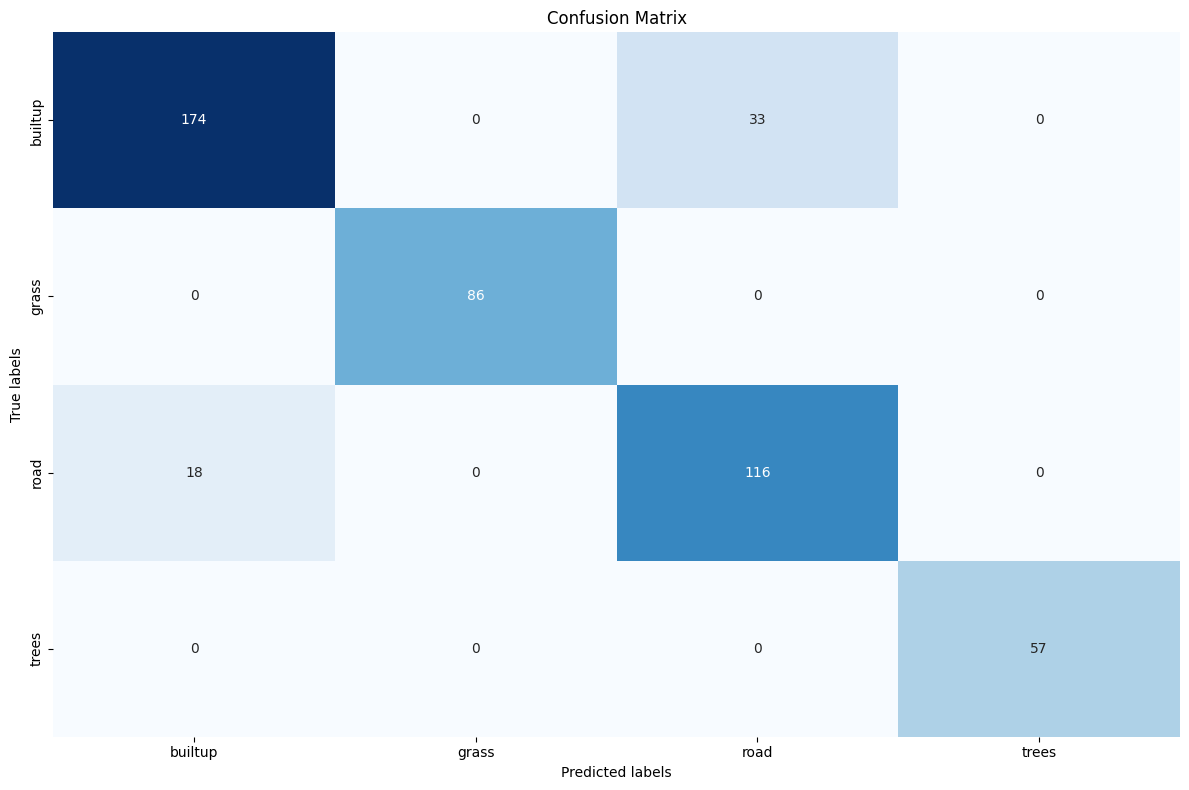

In [12]:
label_mapping = {0: 'builtup', 1: 'grass', 2: 'road', 3: 'trees'}
class_names_str = [label_mapping[label] for label in lr.classes_]
vis_ops.plot_confusion_matrix(y_test, y_pred_test, class_names_str)

# Use the data with Feature Engineering

In [13]:
X_train_fe = pd.read_csv("csv_files/X_train_fe.csv")
X_test_fe = pd.read_csv("csv_files/X_test_fe.csv")
X_train_fe.head(1)

,BLUE,GREEN,RED,NIR,SWIR,NDVI,NDBI,REI,BLUE^2,BLUE GREEN,...,SWIR REI,NDVI^2,NDVI NDBI,NDVI REI,NDBI^2,NDBI REI,REI^2,NDVI_bin_non_veg,NDVI_bin_veg,NDVI_dis_encoded
0,373.5,519.5,389.0,3034.0,1991.0,0.772714,-0.207562,0.002342,139502.25,194033.25,...,4.661945,0.597087,-0.160386,0.001809,0.043082,-0.000486,0.000005,0,1,2


In [14]:
# scale the data
X_train_fe_scaled, X_test_fe_scaled = pre_ops.scale_to_minmax(X_train_fe, X_test_fe)

In [15]:
lr = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
lr.fit(X_train_fe_scaled, y_train.values.ravel())

# predict the validation set
y_train_pred_fe = lr.predict(X_train_fe_scaled)
y_pred_test_fe = lr.predict(X_test_fe_scaled)

In [16]:
# calculate the accuracy
print(f"Train Accuracy: {model_ops.calculate_classification_accuracy(y_train, y_train_pred_fe)}")
print(f"Test Accuracy: {model_ops.calculate_classification_accuracy(y_test, y_pred_test_fe)}")


Train Accuracy: (0.9204134366925064, 0.9239209937262116, 0.9204134366925064, 0.92102251482132)
Test Accuracy: (0.9111570247933884, 0.9141963550351554, 0.9111570247933884, 0.9117720133066353)


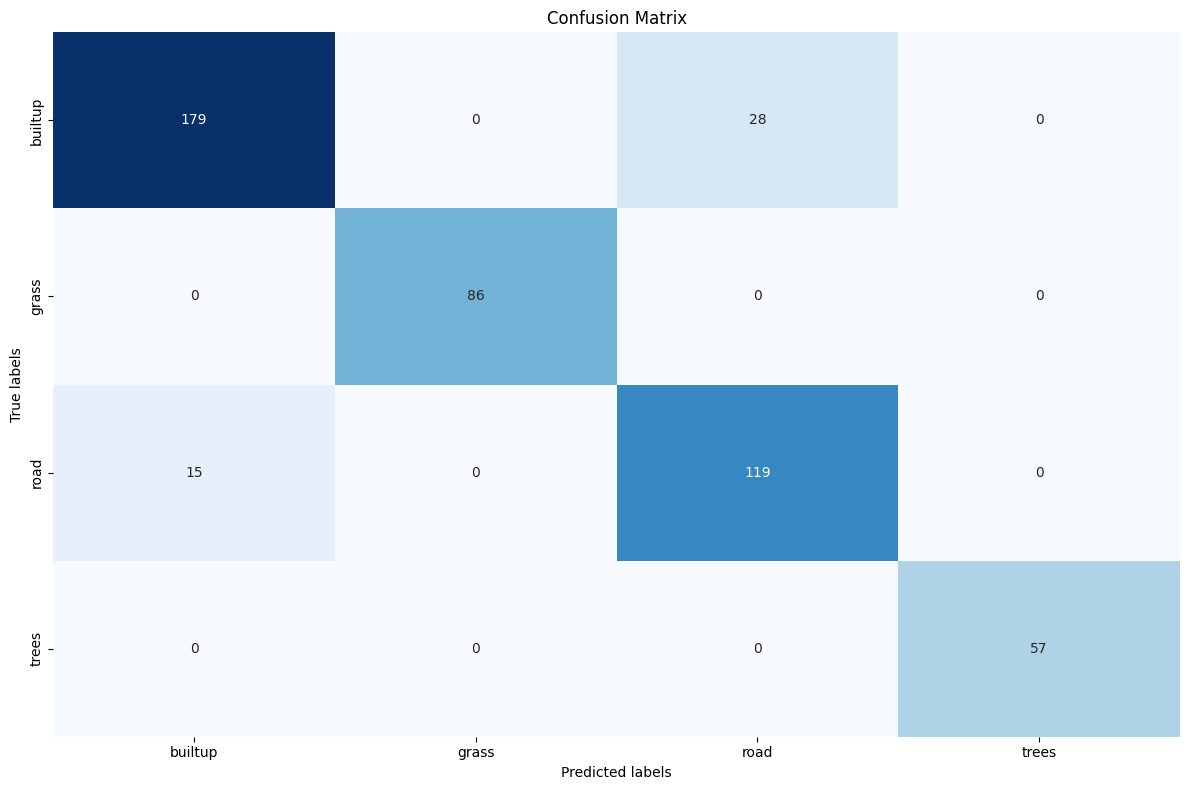

In [17]:
label_mapping = {0: 'builtup', 1: 'grass', 2: 'road', 3: 'trees'}
class_names_str = [label_mapping[label] for label in lr.classes_]
vis_ops.plot_confusion_matrix(y_test, y_pred_test_fe, class_names_str)

END